# TASK 1. Image classification + OOP

**Author: Katerynych Danylo**

GitHub: https://github.com/KaterinichDanilo/Winstars_Internship_test 

MNIST set is a large collection of  images of square 28x28 pixel grayscale images of handwritten single digits between 0 and 9. My goal is to build and compare 3 classification models:
* Random Forest
* Feed-Forward Neural Network
* Convolutional Neural Network

First of all lets import MNIST and split it into train and test datasets.

In [2]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

mnist = fetch_openml('mnist_784')
x, y = mnist["data"], mnist["target"]
y = y.astype(int)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=10)

Lets check demension of imported data

In [3]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(49000, 784) (49000,)
(21000, 784) (21000,)


Expected (49000, 784), (49000,) and (21000, 784), (21000,). We can see that the 2D 28x28 images have already been flattened into one-dimensional vectors of length 784 ($28 \times 28 = 784$). We must take this into account when constructing our models. Let's show every number image from dataset.

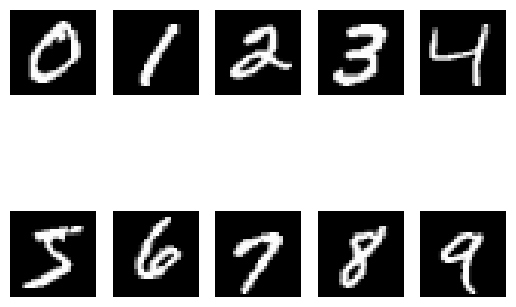

In [4]:
import numpy as np
import matplotlib.pyplot as plt

X_numpy = x.to_numpy()

for digit in range(10):
    idx = np.where(y == digit)[0][0]
    image = X_numpy[idx].reshape(28, 28)
    
    plt.subplot(2, 5, digit + 1)
    plt.imshow(image, cmap='gray')
    plt.axis('off')

## MnistClassifierInterface

We designed a base interface called MnistClassifierInterface. This interface defines two abstract methods: train and predict. All models we develop must implement this interface.

In [5]:
from abc import ABC, abstractmethod

class MnistClassifierInterface(ABC):

    @abstractmethod
    def train(self, x_train, y_train):
        pass

    @abstractmethod
    def predict(self, x_test):
        pass

## Random forest

In [6]:
from sklearn.ensemble import RandomForestClassifier

class RandomForestModel(MnistClassifierInterface):
    def __init__(self, n_estimators=100):
        self.model = RandomForestClassifier(
            n_estimators=n_estimators,
            n_jobs=-1,
            random_state=1
        )
        self.model_type = "RandomForest"

    @staticmethod
    def reshape_data(x):
        x_array = np.array(x)

        # (N, 784) -> just normalize
        if len(x_array.shape) == 2 and x_array.shape[1] == 784:
            return x_array / 255.0

        # (N, 28, 28) -> reshape to (N, 784) and normalize
        if len(x_array.shape) == 3:
            return x_array.reshape(x_array.shape[0], -1) / 255.0

        # If one image (28, 28) -> reshape to (784) and normalize
        if len(x_array.shape) == 2 and x_array.shape[0] == 28:
            return x_array.reshape(1, -1) / 255.0

        return x_array / 255.0

    def train(self, x_train, y_train):
        x_reshaped = self.reshape_data(x_train)
        self.model.fit(x_reshaped, y_train)

    def predict(self, x_test):
        x_reshaped = self.reshape_data(x_test)
        return self.model.predict(x_reshaped)

Let's explain what we have done here. In method __init__ we we initialize the RandomForestClassifier from sklearn. We chose basics parameters 
* n_estimators=100 - the number of trees in the model. This number is enough for the model to make accurate predictions without being too cumbersome.
* n_jobs=-1 It tells Scikit-learn to use all available cores.
* random_state=1 Is necessary for reproducibility of results

Then we created static method reshape_data. Being static, it belongs to the class itself rather than a specific instance, which is ideal for a utility function. This method is needed so that our model can work regardless of the dimension of the transmitted image. We handle three cases: 
* when input data is array of vectors with length 784 (N, 784)
* input data is array of 2D images $28 \times 28$ (N, 28, 28)
* input data is one image $28 \times 28$.

The method normalizes all inputs into a consistent format (an array of vectors with length $28 \times 28=784$). In methods train and predict we just call method reshape_data and then we call appropriate method of our model.

##  Feed-Forward Neural Network

In [25]:
import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class NeuralNetworkClassifier(MnistClassifierInterface, nn.Module):
    def __init__(self):
        super(NeuralNetworkClassifier, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 32),
            nn.ReLU(),

            nn.Linear(32, 10),
        )
        self.loss_fn = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.parameters(), lr=0.01)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer,
                                                                    'min', patience=3, factor=0.5)
        self.model_type = "Feed Forward Neural Network"

    def forward(self, x):
        return self.layers(x)

    @staticmethod
    def reshape_data(x):
        x_array = np.array(x).astype(float)

        # (N, 784)
        if len(x_array.shape) == 2 and x_array.shape[1] == 784:
            x_array /= 255.0

        # (N, 28, 28)
        if len(x_array.shape) == 3:
            x_array = x_array.reshape(x_array.shape[0], -1) / 255.0

        # (28, 28)
        if len(x_array.shape) == 2 and x_array.shape[0] == 28:
            x_array = x_array.reshape(1, -1) / 255.0

        return torch.from_numpy(x_array).float()

    def train(self, x_train, y_train):
        nn.Module.train(self, True)
        x_tensor = NeuralNetworkClassifier.reshape_data(x_train)
        y_tensor = torch.tensor(np.array(y_train), dtype=torch.int64)
        train_dataset = TensorDataset(x_tensor, y_tensor)
        train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)

        epochs = 20

        for epoch in range(epochs):
            running_loss = 0.
            epoch_loss = 0.

            for i, (inputs, labels) in enumerate(train_loader):
                self.optimizer.zero_grad()
                prediction = self.forward(inputs)
                # Compute the loss and its gradients
                loss = self.loss_fn(prediction, labels)
                loss.backward()
                # Adjust learning weights
                self.optimizer.step()

                running_loss += loss.item()
                epoch_loss += loss.item()

                if i % 100 == 99:
                    last_loss = running_loss / 100  # loss per batch
                    # print('epoch {}  batch {} loss: {}'.format(epoch + 1, i + 1, last_loss))
                    running_loss = 0.

            avg_epoch_loss = epoch_loss / len(train_loader)

            print('Epoch {}/{}, average loss per epoch = {}'.format(epoch + 1, epochs, avg_epoch_loss))
                
            
            # Adjust learning rate schedule
            self.scheduler.step(avg_epoch_loss)

    def predict(self, x_test):
        nn.Module.train(self, False)
        x_tensor = NeuralNetworkClassifier.reshape_data(x_test)

        if len(x_tensor) > 500:
            test_dataset = TensorDataset(x_tensor)
            test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)
            all_predictions = []

            with torch.no_grad():
                for batch in test_loader:
                    output = self.forward(batch[0])
                    _, predicted = torch.max(output, 1)
                    all_predictions.append(predicted)

            return np.concatenate(all_predictions)

        with torch.no_grad():
            output = self.forward(x_tensor)
            _, predicted = torch.max(output, 1)

        return predicted.numpy()

Here we have implemented a fully connected neural network (Multi-Layer Perceptron). It takes a vector of length 784 as input. The architecture consists of three hidden layers with 256, 128, and 32 neurons respectively, each utilizing the ReLU activation function. At the output we get a vector of length 10 (one neuron for each digit from 0 to 9). As loss function we use CrossEntropyLoss which is good for multi-class classification problem. As optimization algorithm we choose Adam. For more effective training we use learning rate schedule ReduceLROnPlateau. This scheduler monitors the training loss and reduces the learning rate by a factor of 0.5 if no improvement is observed for 3 consecutive epochs. In train and predict methods we use DataLoader to process the data in batches (size 64). This approach is more memory-efficient and leads to more stable gradient updates.

## Convolutional Neural Network

In [24]:
class CNNClassifier(MnistClassifierInterface, nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        self.cnn_layers = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1),
            nn.ReLU(),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            nn.Dropout2d(0.2)
        )

        self.linear_layers = nn.Sequential(
            nn.Flatten(),

            nn.Linear(in_features=9216, out_features=128),
            nn.ReLU(),

            nn.Linear(in_features=128, out_features=64),
            nn.ReLU(),

            nn.Linear(in_features=64, out_features=10)
        )

        self.optimizer = optim.Adam(self.parameters(), lr=0.001)
        self.loss_fn = nn.CrossEntropyLoss()
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer,
                                                                    'min', patience=3, factor=0.5)
        self.model_type = "Convolutional Neural Network"

    def forward(self, x):
        x = self.cnn_layers(x)
        x = self.linear_layers(x)
        return x

    @staticmethod
    def reshape_data(x):
        x_array = np.array(x, dtype=np.float32)

        if x_array.ndim == 2 and x_array.shape[1] == 784: # (N, 784)
            x_array = x_array.reshape(-1, 1, 28, 28)
        elif x_array.ndim == 3:  # (N, 28, 28)
            x_array = x_array.reshape(-1, 1, 28, 28)

        return torch.from_numpy(x_array / 255.0).float()

    def train(self, x_train, y_train):
        nn.Module.train(self, True)
        x_tensor = CNNClassifier.reshape_data(x_train)
        y_tensor = torch.tensor(np.array(y_train), dtype=torch.int64)
        train_dataset = TensorDataset(x_tensor, y_tensor)
        train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)

        epochs = 20

        for epoch in range(epochs):
            running_loss = 0.
            epoch_loss = 0.

            for i, (data, labels) in enumerate(train_loader):
                self.optimizer.zero_grad()
                predictions = self.forward(data)
                loss = self.loss_fn(predictions, labels)
                loss.backward()
                self.optimizer.step()
                running_loss += loss.item()
                epoch_loss += loss.item()

                if i % 100 == 99:
                    last_loss = running_loss / 100  # loss per batch
                    # print('epoch {}  batch {} loss: {}'.format(epoch + 1, i + 1, last_loss))
                    running_loss = 0.

            avg_epoch_loss = epoch_loss / len(train_loader)
            self.scheduler.step(avg_epoch_loss)
            
            print('Epoch {}/{}, average loss per epoch = {}'.format(epoch + 1, epochs, avg_epoch_loss))
            

    def predict(self, x_test):
        nn.Module.train(self, False)
        x_tensor = CNNClassifier.reshape_data(x_test)

        if len(x_tensor) > 500:
            test_dataset = TensorDataset(x_tensor)
            test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
            all_predictions = []

            with torch.no_grad():
                for batch in test_loader:
                    outputs = self.forward(batch[0])
                    _, predicted = torch.max(outputs, 1)
                    all_predictions.append(predicted.numpy())

            return np.concatenate(all_predictions)

        with torch.no_grad():
            outputs = self.forward(x_tensor)
            _, predicted = torch.max(outputs, 1)

            return predicted.numpy()

For our CNN we implemented the next architecture:
* first convolution layer: takes picture ($1 \times 28 \times 28$) and convert it to ($32 \times 26 \times 26$) feature map and then ReLu activation function is used
* second convolution layer: takes feature map ($32 \times 26 \times 26$) and convert it to ($64 \times 24 \times 24$) and then activation function ReLu is used
* Max Pooling: reduces the spatial dimensions of feature map by half (because kernel_size=2) and the result has dimension ($64 \times 12 \times 12$)
* Dropou2D: randomly diactivates 20% of neurons to reduce the chance of overfitting
* Then we flatten the result of polling into vector with length $64 \times 12 \times 12 = 9216$
* This vector passes through two hidden dense layers. Result is vector with length 10 that provides the classification probabilities for digits 0–9

The last important difference between CNN and NN is reshape_data. For CNN we reshape input data to get 2D images $1 \times 28 \times 28$

## MnistClassifier

In [9]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import seaborn as sns

class MnistClassifier():
    def __init__(self, model_type: str):
        if model_type == "rf":
            self.model = RandomForestModel()
        elif model_type == "cnn":
            self.model = CNNClassifier()
        elif model_type == "nn":
            self.model = NeuralNetworkClassifier()
        else:
            raise ValueError("Invalid model type")

    def train(self, x_train, y_train):
        print(f"{self.model.model_type} start training...")
        self.model.train(x_train, y_train)
        print(f"{self.model.model_type} training finished")

    def predict(self, x_test):
        return self.model.predict(x_test)

    def evaluate(self, x_test, y_test):
        print(f"Evaluating model {self.model.model_type}")
        y_pred = self.model.predict(x_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        print(f'Accuracy: {accuracy:.4f}\n'
              f'Precision: {precision:.4f}\n'
              f'Recall: {recall:.4f}\n'
              f'F1 score: {f1:.4f}')

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - {self.model.model_type}')
        plt.ylabel('Actual Label')
        plt.xlabel('Predicted Label')
        plt.show()

        return y_pred

The MnistClassifier class is a wrapper class. It implements methods for creating one of the models, training the model, getting predictions of the model, and also a method for evaluating the model in which metrics are calculated. We calculate the next metrics:
* Accuracy
* Precision
* Recall
* F1 score

Also we show the confussion matrix.

## Evaluating models

Let's create instances of the MnistClassifier class for Random Forest, NN, and CNN models. We will train the models, evaluate them on the test set, and analyze the results.

RandomForest start training...
RandomForest training finished
Evaluating model RandomForest
Accuracy: 0.9662
Precision: 0.9662
Recall: 0.9662
F1 score: 0.9662

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2112
           1       0.98      0.99      0.99      2284
           2       0.96      0.96      0.96      2117
           3       0.96      0.96      0.96      2160
           4       0.96      0.96      0.96      2038
           5       0.96      0.96      0.96      1881
           6       0.98      0.98      0.98      2009
           7       0.98      0.97      0.97      2253
           8       0.95      0.95      0.95      2057
           9       0.95      0.94      0.95      2089

    accuracy                           0.97     21000
   macro avg       0.97      0.97      0.97     21000
weighted avg       0.97      0.97      0.97     21000



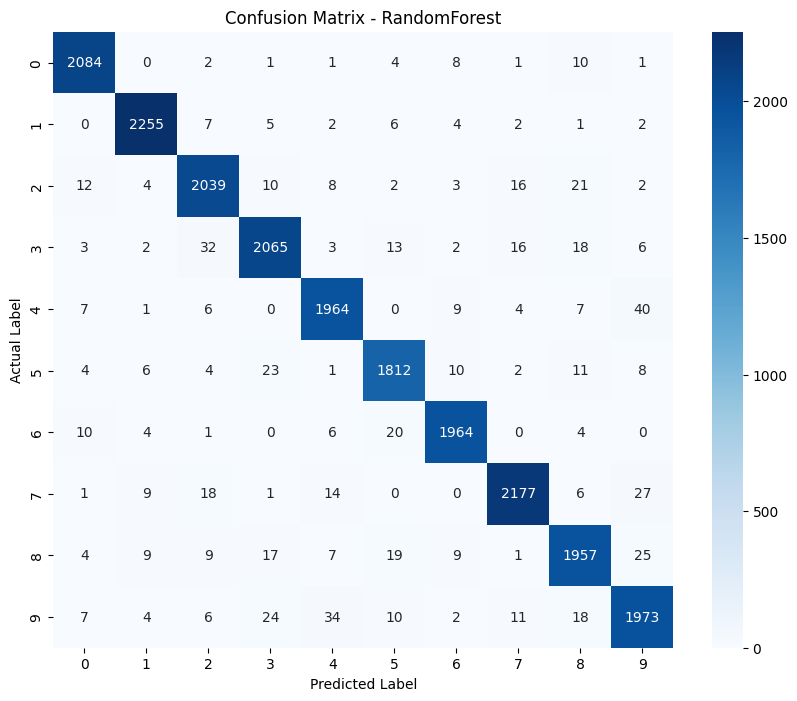

In [10]:
# Create random forest model
random_forest = MnistClassifier('rf')
# Train random forest
random_forest.train(x_train, y_train)
# Evaluate the model (calculate metrics and confusion matrix)
random_forest_pred = random_forest.evaluate(x_test, y_test)

Let's look at Classification Report. Presision 0.98 for class '0' means when the model predicts the number as 0, it is correct 98% of the time. We can see that the highest precision is for classes **0, 1, 6, 7**. And the lowest is for classes **8, 9**. If we look at the confusion matrix, we will see that in the row with actual label 4 and in the column with predicted label 9 there is a high value 40. That means that the model has classified 4 as 9 for 40 times. We also can see that the model classified 9 as 4 for 34 times. The model does not distinguish well between these two classes. We can say the same about the pair of classes **(2, 8), (3, 9), (8, 9)**. Recall 0.99 for classes **0, 1** means the model correctly identified 99% of numbers 0 and 1. Class **9** has the lowest recall - 0.94. Let's show the misclassified cases graphically.


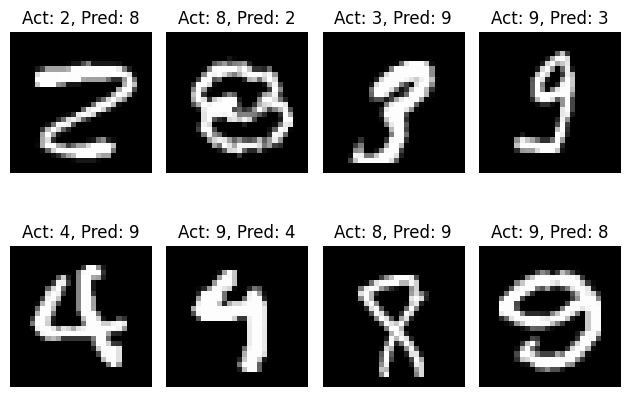

In [22]:
y_test_array = np.array(y_test).astype(int)

actual_pred_labels = [[2, 8], [8, 2], [3, 9], [9, 3], [4, 9], [9, 4], [8, 9], [9, 8]]

for i, (actual_label, predicted_label) in enumerate(actual_pred_labels):
    misclassified_indices = np.where((y_test == actual_label) & (random_forest_pred == predicted_label) & (random_forest_pred != y_test_array))[0]

    idx = misclassified_indices[0]
    img = np.array(x_test)[idx].reshape(28, 28)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Act: {y_test_array[idx]}, Pred: {random_forest_pred[idx]}")
    plt.axis('off')
plt.tight_layout()


Now we create, train and evaluate Neural Network model. Note that for this implementation, the training process is set to 20 epochs to ensure the model has sufficient iterations to converge and minimize the loss. If you want to reduce the time of training, you can change this number in method train.

Feed Forward Neural Network start training...
Epoch 0/20, average loss per epoch = 0.2936772338598578
Epoch 1/20, average loss per epoch = 0.15133212216553465
Epoch 2/20, average loss per epoch = 0.12839976166297168
Epoch 3/20, average loss per epoch = 0.11323891553235077
Epoch 4/20, average loss per epoch = 0.11142307740995447
Epoch 5/20, average loss per epoch = 0.094126849859897
Epoch 6/20, average loss per epoch = 0.08759410994904153
Epoch 7/20, average loss per epoch = 0.08316355880116816
Epoch 8/20, average loss per epoch = 0.08227852643894545
Epoch 9/20, average loss per epoch = 0.08190282473387972
Epoch 10/20, average loss per epoch = 0.07827855523154546
Epoch 11/20, average loss per epoch = 0.06572706489482852
Epoch 12/20, average loss per epoch = 0.0681873845970436
Epoch 13/20, average loss per epoch = 0.06561373782481475
Epoch 14/20, average loss per epoch = 0.07245512459633505
Epoch 15/20, average loss per epoch = 0.07202862188892224
Epoch 16/20, average loss per epoch = 0.

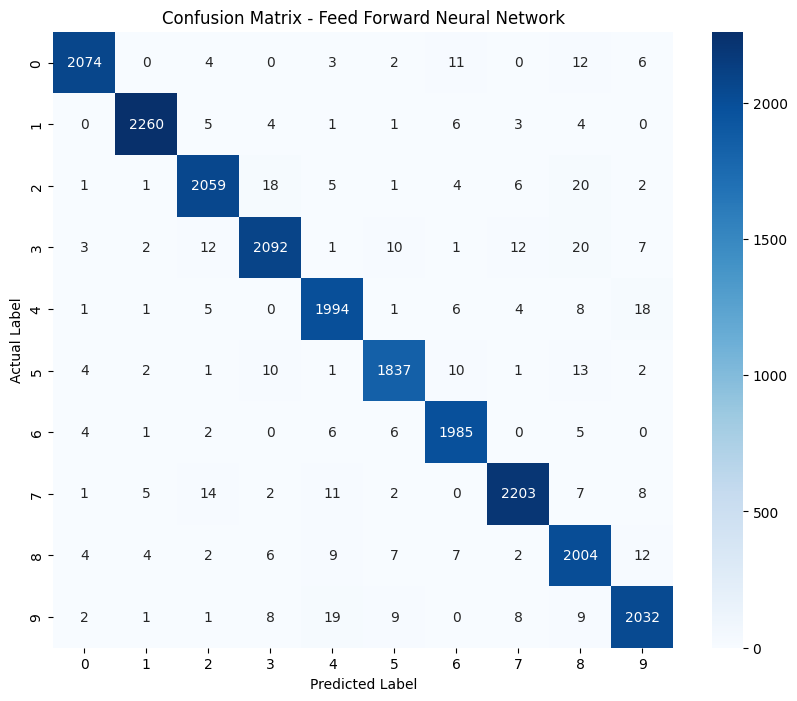

In [21]:
# Create Neural Network model
neural_network = MnistClassifier('nn')
neural_network.train(x_train, y_train)
neural_network_pred = neural_network.evaluate(x_test, y_test)

If we analyze the metrics for the neural network, we see that it performed slightly better than the random forest. The neural network is better at distinguishing between classes (8, 9), (3, 9), (4, 9). For example, for class 9, precision and recall increased by 1 to 4 percent. In the confusion matrix, we see that the number of False Positives has decreased significantly. For example, in case **(Actual label: 4, Predicted label: 9)** we got 29 FP, for Random Forest it was 40. In case **(Actual label: 9, Predicted label: 3)** we got 5 FP, for Random Forest it was 24. This indicates that we have successfully chosen the neural network architecture.

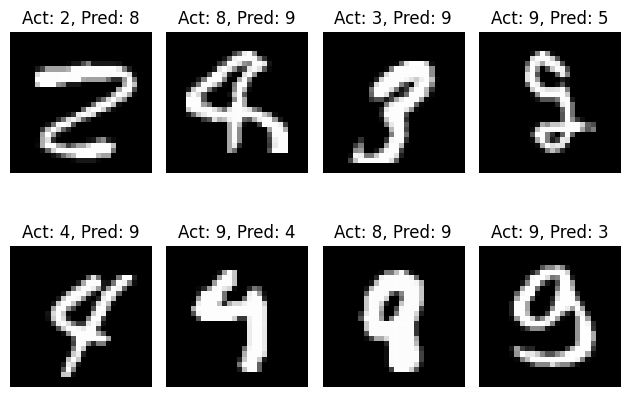

In [26]:
y_test_array = np.array(y_test).astype(int)

actual_pred_labels = [[2, 8], [8, 2], [3, 9], [9, 3], [4, 9], [9, 4], [8, 9], [9, 8]]

for i, (actual_label, predicted_label) in enumerate(actual_pred_labels):
    misclassified_indices = np.where((y_test == actual_label) & (random_forest_pred == predicted_label) & (neural_network_pred != y_test_array))[0]

    idx = misclassified_indices[0]
    img = np.array(x_test)[idx].reshape(28, 28)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Act: {y_test_array[idx]}, Pred: {neural_network_pred[idx]}")
    plt.axis('off')
plt.tight_layout()

Now let's train and evaluate Convolution Neural Network. Note that CNN takes significantly longer to train than NN. This is because CNN requires more computation than NN. As for NN, we trained CNN on 20 epochs.

In [ ]:
cnn = MnistClassifier('cnn')
cnn.train(x_train, y_train)

Convolutional Neural Network start training...
Epoch 1/20, average loss per epoch = 0.2088850488656446


Evaluating model Convolutional Neural Network
Accuracy: 0.9894
Precision: 0.9894
Recall: 0.9894
F1 score: 0.9894

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2112
           1       0.99      1.00      0.99      2284
           2       0.99      0.99      0.99      2117
           3       0.99      0.99      0.99      2160
           4       0.99      0.98      0.99      2038
           5       0.98      0.99      0.99      1881
           6       0.99      0.99      0.99      2009
           7       0.99      0.99      0.99      2253
           8       0.99      0.99      0.99      2057
           9       0.99      0.99      0.99      2089

    accuracy                           0.99     21000
   macro avg       0.99      0.99      0.99     21000
weighted avg       0.99      0.99      0.99     21000



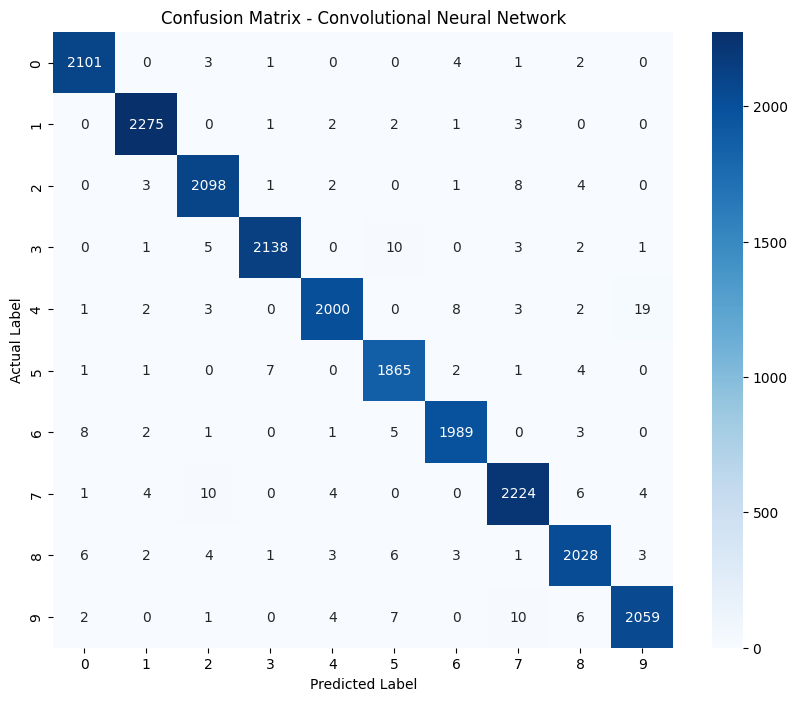

In [47]:
cnn_pred = cnn.evaluate(x_test, y_test)

Compared to the two previous models, CNN showed the best result. For almost all classes, prediction and recall are equal to 0.99, which is an improvement over the previous result. This indicates that the model is remarkably stable and does not have weak spots like previous ones. The model confidently distinguishes classes. The model successfully resolved the confusion between pairs like (4, 9) and (8, 2) that were problematic for the Random Forest and MLP. 

We can say that CNN is the best model for image classification MNIST.

## Noise resistance of models

Let's examine how robust the models are to noise. To do this, we add normally distributed noise to the test data.

In [60]:
x_test_numpy = x_test.to_numpy()

noise_level = 30
x_test_noisy = x_test_numpy + noise_level * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

Now we show digits with labels 0..4 before and after noising. 

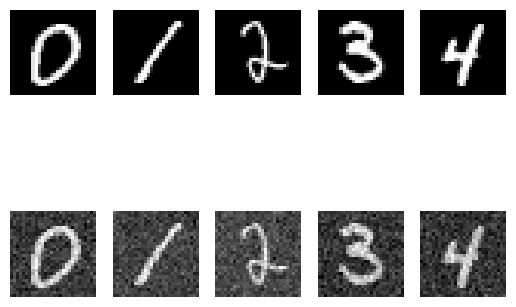

In [61]:
for digit in range(5):
    idx = np.where(y_test == digit)[0][0]
    image = x_test_numpy[idx].reshape(28, 28)
    image_noisy = x_test_noisy[idx].reshape(28, 28)
    
    plt.subplot(2, 5, digit + 1)
    plt.imshow(image, cmap='gray')
    plt.axis('off')

    plt.subplot(2, 5, digit + 6)
    plt.imshow(image_noisy, cmap='gray')
    plt.axis('off')

Let's evaluate our three models on noisy data

Evaluating model RandomForest
Accuracy: 0.6973
Precision: 0.7993
Recall: 0.6973
F1 score: 0.6620

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      2112
           1       1.00      0.03      0.05      2284
           2       0.61      0.89      0.73      2117
           3       0.72      0.89      0.79      2160
           4       0.81      0.82      0.81      2038
           5       0.76      0.80      0.78      1881
           6       0.94      0.89      0.92      2009
           7       0.99      0.38      0.55      2253
           8       0.40      0.97      0.57      2057
           9       0.83      0.43      0.57      2089

    accuracy                           0.70     21000
   macro avg       0.80      0.71      0.67     21000
weighted avg       0.80      0.70      0.66     21000



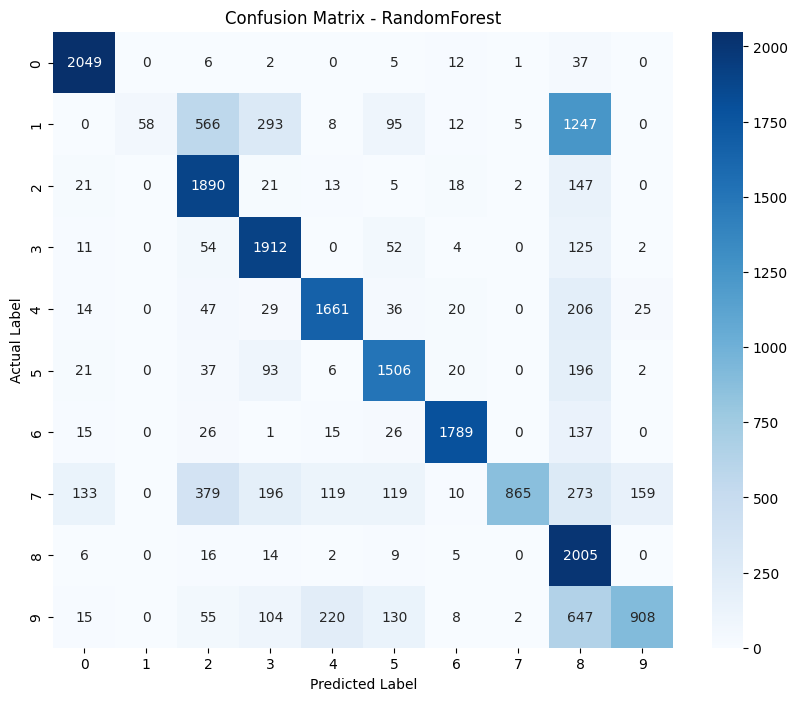

array([6, 8, 8, ..., 2, 3, 2], shape=(21000,))

In [62]:
random_forest.evaluate(x_test_noisy, y_test)

Evaluating model Feed Forward Neural Network
Accuracy: 0.9698
Precision: 0.9700
Recall: 0.9698
F1 score: 0.9698

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2112
           1       0.99      0.98      0.99      2284
           2       0.97      0.97      0.97      2117
           3       0.97      0.96      0.97      2160
           4       0.97      0.96      0.97      2038
           5       0.98      0.96      0.97      1881
           6       0.97      0.99      0.98      2009
           7       0.98      0.96      0.97      2253
           8       0.94      0.96      0.95      2057
           9       0.94      0.97      0.96      2089

    accuracy                           0.97     21000
   macro avg       0.97      0.97      0.97     21000
weighted avg       0.97      0.97      0.97     21000



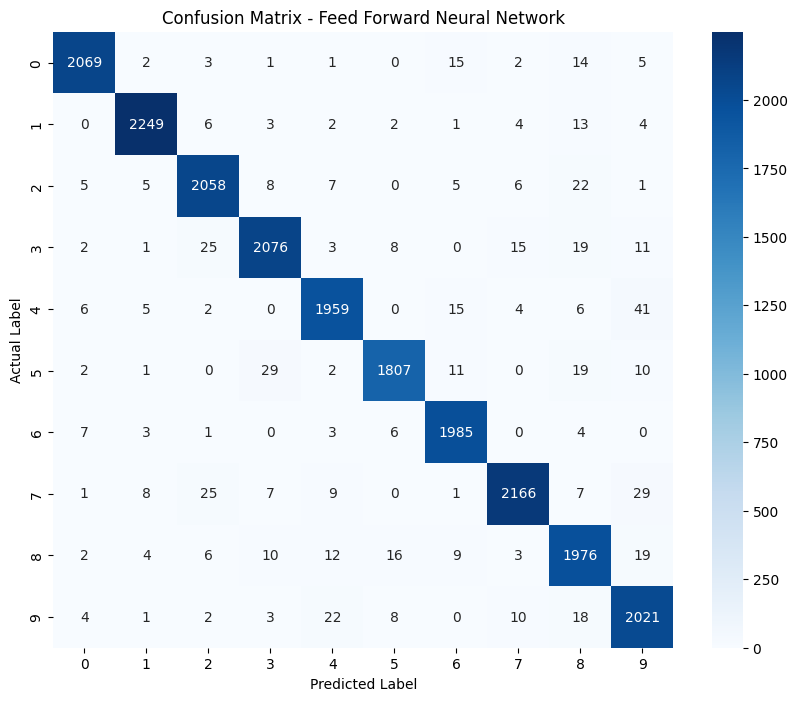

array([6, 7, 5, ..., 2, 3, 1], shape=(21000,))

In [63]:
neural_network.evaluate(x_test_noisy, y_test)

Evaluating model Convolutional Neural Network
Accuracy: 0.9885
Precision: 0.9885
Recall: 0.9885
F1 score: 0.9885

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2112
           1       0.99      1.00      0.99      2284
           2       0.98      0.99      0.99      2117
           3       0.99      0.99      0.99      2160
           4       0.99      0.99      0.99      2038
           5       0.98      0.99      0.99      1881
           6       0.99      0.99      0.99      2009
           7       0.98      0.99      0.98      2253
           8       0.99      0.99      0.99      2057
           9       0.99      0.98      0.98      2089

    accuracy                           0.99     21000
   macro avg       0.99      0.99      0.99     21000
weighted avg       0.99      0.99      0.99     21000



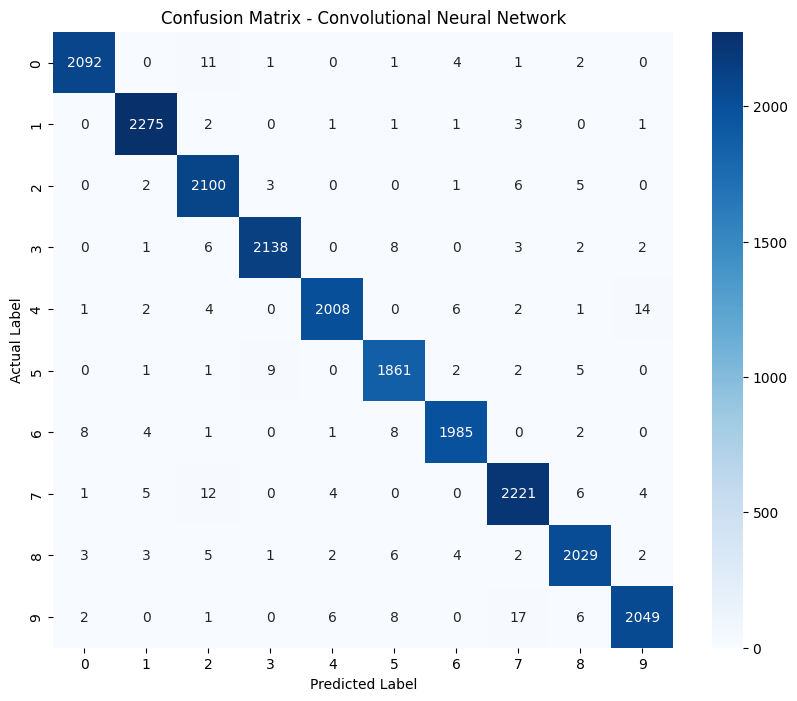

In [64]:
cnn.evaluate(x_test_noisy, y_test)

Now let's compare metrics of three models before and after noising the data. 

| Модель | F1 score (no noise) | F1 score (with noise) | Differense (Robustness) |
| :--- | :---: | :---: | :--- |
| **Random Forest** | 0.9662 | 0.662 | -0.3042 |
| **Neural Network** | 0.9759 | 0.9698 | -0.0061 |
| **CNN** | 0.9894 | 0.9885 | -0.0009 |

As we can see, the CNN model is the most resistant to noise.